# **TS3** Desparramo Espectral.
García Corona, Iara Paula<br><br>
Este trabajo propone observar el fenómeno dado al calcular la FFT de una señal: el desparramo espectral. Para esto se busca generar una señal con dependencia del $k_0$, constante adimensional que ubica la frecuencia de la señal respecto a los bins y probar sus límites para poder visualizar el efecto. En un caso ideal, $k_0$ es un número entero y la frecuencia de la señal coincide exactamente con un bin de frecuencia; en este trabajo se lo desintoniza para poder visualizar qué ocurre cuando esa condición no se cumple.<br>
En segunda instancia se busca evidenciar, a través de la **Identidad de Parseval**, que la potencia de la señal se puede obtener a partir del área bajo la densidad espectral de potencia en el dominio de la frecuencia.<br>
Finalmente, se repite el análisis de la misma señal aplicando la técnica de zero padding, con el fin de observar su efecto sobre el espectro.

https://numpy.org/doc/stable/reference/generated/numpy.pad.html

Se establecen las funciones, parámetros generales y se generan los valores de las señales que se van a utilizar a lo largo de todo el trabajo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    xx=dc+vmax*np.sin(2*np.pi*ff*nn/fs+2*np.pi*ph)
    tt=nn/fs
    return(tt,xx)

def espectro(xx,N):
    tr=(1/N)*np.fft.fft(xx)
    modulo_tr=np.abs(tr)
    return modulo_tr

In [2]:
# Parámetros
fs = 1000 # Hz
N = 1000 # muestras
nn=np.arange(0,N)

#Señal de entrada
pot_seno=1
vmax=np.sqrt(pot_seno*2) # (potencial máximo aka apmlitud máxima)
dc=0 # Valor medio (alrededor del que oscila)
df=fs/N # resolucion espectral
k0_0=N/4
k0_1=N/4+0.25
k0_2=N/4+0.5

f_sen0=k0_0*df #frecuencia => fk=k*fs/N
f_sen1=k0_1*df
f_sen2=k0_2*df
ph=0
k = np.arange(0,N)
frec= k * fs/N

# Señal pura analógica
tt0, xx0= mi_funcion_sen(vmax, dc, f_sen0, ph, nn, fs)
tt1, xx1= mi_funcion_sen(vmax, dc, f_sen1, ph, nn, fs)
tt2, xx2= mi_funcion_sen(vmax, dc, f_sen2, ph, nn, fs)

Para los distintos $k_0$ se definen nuevas variables vinculadas que permiten generar los vectores de tiempo y amplitud.<br>
Se grafican las densidades espectrales de potencia correspondientes a las tres señales.

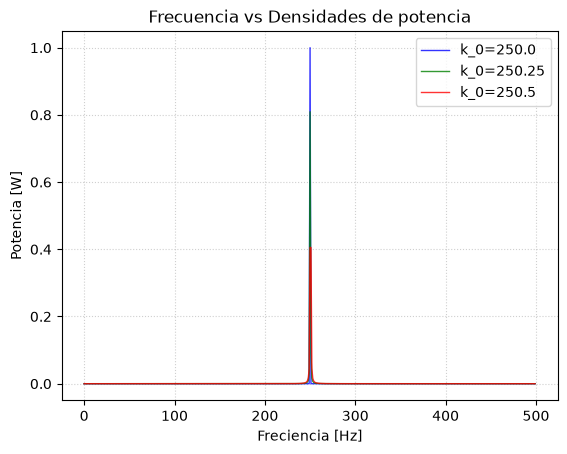

In [3]:
# Espectro completo

P_0=2*espectro(xx0,N)**2 #esto sería |espectro|^2 pero en mi función espectro ya tengo hecho el módulo
P_1=2*espectro(xx1,N)**2
P_2=2*espectro(xx2,N)**2

fig=plt.figure()
plt.plot(frec[:N//2], P_0[:N//2], color='blue', linewidth=1, alpha=0.8, label=f"k_0={k0_0}")
plt.plot(frec[:N//2], P_1[:N//2], color='green', linewidth=1, alpha=0.8, label=f"k_0={k0_1}")
plt.plot(frec[:N//2], P_2[:N//2], color='red', linewidth=1, alpha=0.8, label=f"k_0={k0_2}")
plt.title("Frecuencia vs Densidades de potencia")
plt.xlabel("Freciencia [Hz]")
plt.ylabel("Potencia [W]")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
plt.close(fig)

A medida que se aumenta el corrimiento de la señal sobre el bin entero central, en este caso $250Hz$, se puede observar una baja en la amplitud total. Para poder verlo con mayor detenimiento se realiza un zoom en el área de interés.

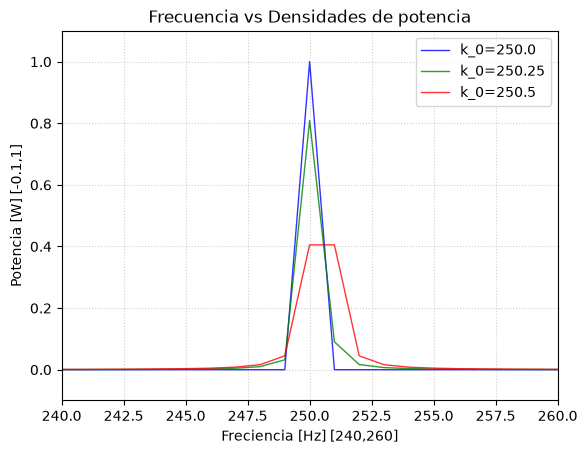

In [4]:
# Zoom Espectro
fig=plt.figure()
plt.plot(frec[:N//2], P_0[:N//2], color='blue', linewidth=1, alpha=0.8, label=f"k_0={k0_0}")
plt.plot(frec[:N//2], P_1[:N//2], color='green', linewidth=1, alpha=0.8, label=f"k_0={k0_1}")
plt.plot(frec[:N//2], P_2[:N//2], color='red', linewidth=1, alpha=0.8, label=f"k_0={k0_2}")
plt.xlim(240,260)
plt.ylim(-0.1,1.1)
plt.title("Frecuencia vs Densidades de potencia")
plt.xlabel("Freciencia [Hz] [240,260]")
plt.ylabel("Potencia [W] [-0.1,1]")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
plt.close(fig)

Con el zoom se puede ver la baja de la amplitud con mayor claridad y además permite ver que el decaimiento tiene una leve inclinación en la base, debido al solapamiento entre las frecuencias de bins cercanos. Para $k_0=250$ toda la energía cae en un único bin y la amplitud alcanza el valor máximo; para $k_0=250,25$, el pico se encuentra centrado en el bin 250, pero una pequeña parte de su energía se distribuye entre los dos bins contiguos; para $k_0=250,50$ la frecuencia quedará en el medio de dos bins, por lo que la energía se reparte casi por igual entre ambos, alcanzando aproximadamente su máximo en $\approx 0,4W$, menos de la mitad de la potencia entregada a la señal.

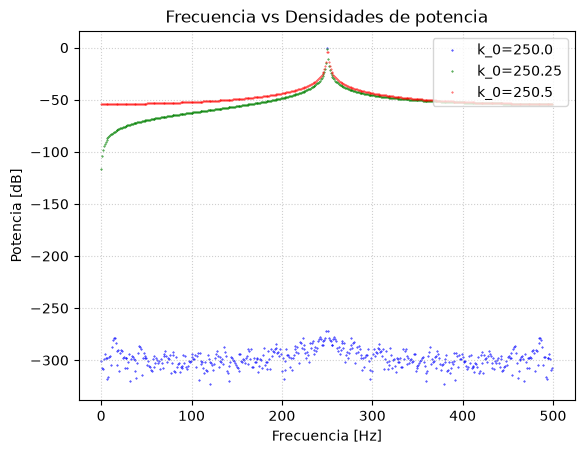

In [5]:
# Gráficos en dB
P_0_db = 10 * np.log10(P_0)
P_1_db = 10 * np.log10(P_1)
P_2_db = 10 * np.log10(P_2)
fig=plt.figure()
plt.plot(frec[:N//2], P_0_db[:N//2], color='blue', label=f"k_0={k0_0}", marker=".", markersize=0.8, linestyle='None', zorder=1)
plt.plot(frec[:N//2], P_1_db[:N//2], color='green', label=f"k_0={k0_1}", marker=".", markersize=0.8, linestyle='None', zorder=2)
plt.plot(frec[:N//2], P_2_db[:N//2], color='red', linewidth=1, alpha=0.8, label=f"k_0={k0_2}", marker=".", markersize=0.8, linestyle='None', zorder=3)
plt.title("Frecuencia vs Densidades de potencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
plt.close(fig)

Realizando un análisis en dB, se puede evidenciar el desparramo espectral, dado que expone el nivel en el que cada frecuencia aporta energía a la componente principal y aledañas. Para $k_0=250$ la energía está concentrada en la frecucencia de bin entero, el piso de ruido ronda los $-300dB$ dado el error de cómputo propio del procesamiento computacional. Para $k_0=250,25$ es el caso intermedio donde las frecuencias próximas al bin entero de interés tienen un aporte apreciable por la señal. Para $k_0=250,50$ las frecuencias que rodean los $250Hz$, si bien no tienen una influencia relevante frente a la señal principal tienen un decaimiento más lento hacia los bordes en el caso entero, lo que refuerza el concepto de pérdida en la componente principal y explica la baja en la amplitud observada en el gráfico anterior.

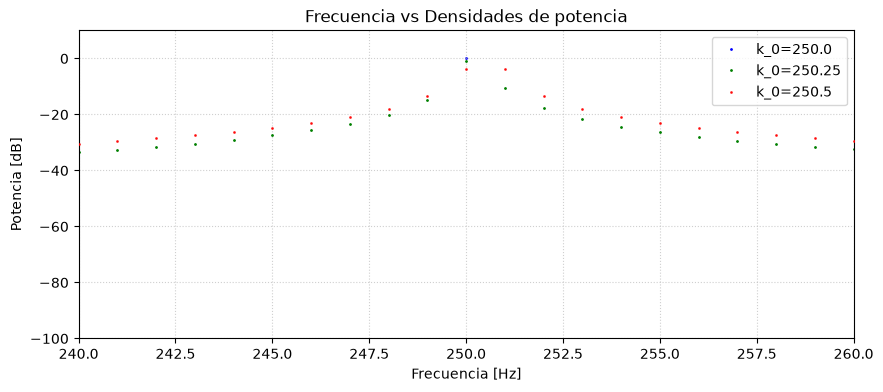

In [6]:
fig=plt.figure(figsize=(10,4))
plt.plot(frec[:N//2], P_0_db[:N//2], color='blue', label=f"k_0={k0_0}", marker=".", markersize=2, linestyle='None', zorder=1)
plt.plot(frec[:N//2], P_1_db[:N//2], color='green', label=f"k_0={k0_1}", marker=".", markersize=2, linestyle='None', zorder=2)
plt.plot(frec[:N//2], P_2_db[:N//2], color='red', linewidth=1, alpha=0.8, label=f"k_0={k0_2}", marker=".", markersize=2, linestyle='None', zorder=3)
plt.xlim(240,260)
plt.ylim(-100,10)
plt.title("Frecuencia vs Densidades de potencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
plt.close(fig)

En esta ampliación en el pico se busca remarcar que el desparramo ocurre hacia la derecha, es decir, hacia el bin 251.

Este es el comportamiento que buscamos generar para visualizar el desparramo espectral. La DFT considera las N muestras como un periodo de la señal periódica infinita. Es decir, que se repite ese bloque de N muestras para armar el espectro. Cuando $k_0$ es entero, la senoidal completa un número exacto de ciclos dentro del periodo, al repetir el bloque periódicamente, el empalme entre estos es perfecto, no hay saltos ni discontinuidades. Es por eso que toda la energía cae en un solo bin.<br>
Cuando $k_0$ no es entero, la senoidal no completa un número entero de ciclos en ese periodo, al repetirlo periódicamente se genera una discontinuidad brusca, la cual no se encuentra en la señal real sino una consecuencia de la repetición periódica de la DFT. Como la DFT solo trabaja con frecuencias de bins enteros, no puede representar la señal real con un único bin, la aproxima combinando frecuencias vecinas definidas en bins enteros, por eso la energía aparece repartida en varios bins en lugar de estar focalizada.

In [7]:
#Parseval
P_total_0=1/N*np.sum(xx0**2)
P_total_1=1/N*np.sum(xx1**2)
P_total_2=1/N*np.sum(xx2**2)
print("En el dominio del tiempo:")
print(f"Potencia total de la señal para k_0=250: {P_total_0:.4f}W")
print(f"Potencia total de la señal para k_0=250,25: {P_total_1:.4f}W")
print(f"Potencia total de la señal para k_0=250,50: {P_total_2:.4f}W")

pot_total_0_frec = (1/N**2) * np.sum(np.abs(np.fft.fft(xx0))**2)
pot_total_1_frec = (1/N**2) * np.sum(np.abs(np.fft.fft(xx1))**2)
pot_total_2_frec = (1/N**2) * np.sum(np.abs(np.fft.fft(xx2))**2)
print("\nEn el dominio de la frecuencia:")
print(f"Potencia total de la señal para k_0=250: {pot_total_0_frec:.4f}W")
print(f"Potencia total de la señal para k_0=250,25: {pot_total_1_frec:.4f}W")
print(f"Potencia total de la señal para k_0=250,50: {pot_total_2_frec:.4f}W")

En el dominio del tiempo:
Potencia total de la señal para k_0=250: 1.0000W
Potencia total de la señal para k_0=250,25: 0.9990W
Potencia total de la señal para k_0=250,50: 1.0000W

En el dominio de la frecuencia:
Potencia total de la señal para k_0=250: 1.0000W
Potencia total de la señal para k_0=250,25: 0.9990W
Potencia total de la señal para k_0=250,50: 1.0000W


La identidad de Parseval se verifica para las tres señales en ambos dominios, esto confirma que la FFT no agrega ni elimina energía, solo la redistribuye entre los distintos bins del espectro. Por eso, aunque la amplitud del pico bajaba al desintonizar, esa energía que se perdía en el bin central no desaparecía sino que se mostraba en bins contiguos.<br>
En $k_0=250,25$ es menor a 1, esto se debe a que la senoidal no cumple un número entero de ciclos, este resto de ciclo incompleto hace que el promedio sobre las muestras finitas no sea exactamente el esperado. Si bien es una pequeña diferencia, muestra cómo la potencia en un tramo finito de la señal depende de qué tan bien se sampleen los ciclos completos.<br><br>
Ahora se busca analizar la señal aplicando ***zero padding*** a los valores de amplitud de la señal:

In [8]:
#%% zero padding
N_zero=N+9*N
df_zero=fs/N_zero
nn_zero=np.arange(0,N_zero)
k_zero= np.arange(0,N_zero)
frec_zero= k_zero*fs/N_zero #Esto es lo que yo finalmente buscaba

zero_xx0=np.pad(xx0, (0, 9*N), 'constant', constant_values=0)
zero_xx1=np.pad(xx1, (0, 9*N), 'constant', constant_values=0)
zero_xx2=np.pad(xx2, (0, 9*N), 'constant', constant_values=0)

P_zero_0=2*espectro(zero_xx0,N)**2 #esto sería |espectro|^2 pero en mi función espectro ya tengo hecho el módulo
P_zero_1=2*espectro(zero_xx1,N)**2
P_zero_2=2*espectro(zero_xx2,N)**2

Al paddear la señal, se modifica la resolución espectral a través de la cual la FFT va a analizar las muestras, siendo antes $\Delta f=\frac{fs}{N}=\frac{1000Hz}{1000}=1Hz$ y ahora $\Delta f=\frac{1000Hz}{10000}=0,1Hz$. Esta modificación no elimina el desparramo espectral, pero permite visualizar con mayor detalle la forma real del mismo, mostrando información que no se veía en el original.

In [13]:
#Parseval
P_total_zero_0=1/N*np.sum(zero_xx0**2)
P_total_zero_1=1/N*np.sum(zero_xx1**2)
P_total_zero_2=1/N*np.sum(zero_xx2**2)
print(f"Potencia total de la señal paddeada para k_0=250: {P_total_zero_0:.4f}W")
print(f"Potencia total de la señal paddeada para k_0=250,25: {P_total_zero_1:.4f}W")
print(f"Potencia total de la señal paddeada para k_0=250,50: {P_total_zero_2:.4f}W")

Potencia total de la señal paddeada para k_0=250: 1.0000W
Potencia total de la señal paddeada para k_0=250,25: 0.9990W
Potencia total de la señal paddeada para k_0=250,50: 1.0000W


Por *Identidad de Parseval* es posible corroborar que la potencia de la señal no disminuyó a pesar del aumento de muestras incluidas en el vector de amplitudes. Esto se debe a que la transformada del elemento nulo también lo es, por lo que paddear la señal no agrega energía a la misma.

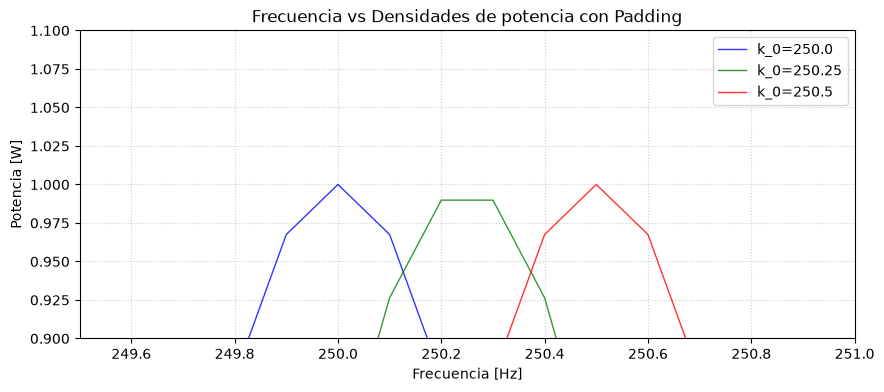

In [23]:
fig=plt.figure(figsize=(10,4))
plt.plot(frec_zero[:N_zero//2], P_zero_0[:N_zero//2], color='blue', linewidth=1, alpha=0.8, label=f"k_0={k0_0}")
plt.plot(frec_zero[:N_zero//2], P_zero_1[:N_zero//2], color='green', linewidth=1, alpha=0.8, label=f"k_0={k0_1}")
plt.plot(frec_zero[:N_zero//2], P_zero_2[:N_zero//2], color='red', linewidth=1, alpha=0.8, label=f"k_0={k0_2}")
plt.title("Frecuencia vs Densidades de potencia con Padding")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [W]")
plt.legend(loc='upper right')
plt.xlim(249.5,251)
plt.ylim(0.9,1.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
plt.close(fig)

Visualizando en gráfico se puede observar cómo ahora dos señales llegan a su punto máximo de potencia, pero no lo hace en $k_0=250,25$, ya que la frecuencia no resulta en un múltiplo entero de $\Delta f$ sino que queda entre los bins $250,20$ y  $250,30$. Esto resulta en un pico achatado dado que la energía se divide entre estos dos bins. Ahora, las señales con $k_0=250$ y  $k_0=250,50$ sí cumplen la condición para poder reflejar con mejor fidelidad la forma de la señal de entrada original.

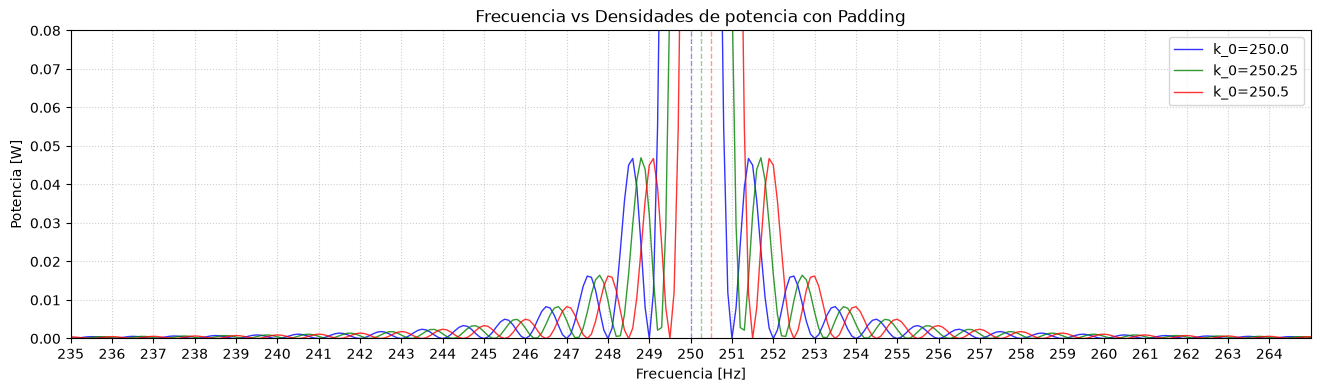

In [45]:
fig=plt.figure(figsize=(16,4))
plt.plot(frec_zero[:N_zero//2], P_zero_0[:N_zero//2], color='blue', linewidth=1, alpha=0.8, label=f"k_0={k0_0}")
plt.plot(frec_zero[:N_zero//2], P_zero_1[:N_zero//2], color='green', linewidth=1, alpha=0.8, label=f"k_0={k0_1}")
plt.plot(frec_zero[:N_zero//2], P_zero_2[:N_zero//2], color='red', linewidth=1, alpha=0.8, label=f"k_0={k0_2}")
plt.xlim(235,265)
plt.xticks(np.arange(235, 265, 1))
plt.ylim(0,0.08)
plt.title("Frecuencia vs Densidades de potencia con Padding")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [W]")
plt.axvline(x=250, color='blue', linestyle='--', linewidth=1, alpha=0.4)
plt.axvline(x=250.25, color='green', linestyle='--', linewidth=1, alpha=0.4)
plt.axvline(x=250.50, color='red', linestyle='--', linewidth=1, alpha=0.4)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
plt.close(fig)

Acercando el foco a la base del espectro, es posible ver cómo la representación azul está centrada en $250Hz$ y asegurar que la verde y la roja están en $250,25Hz$ y $250,50Hz$ respectivamente.

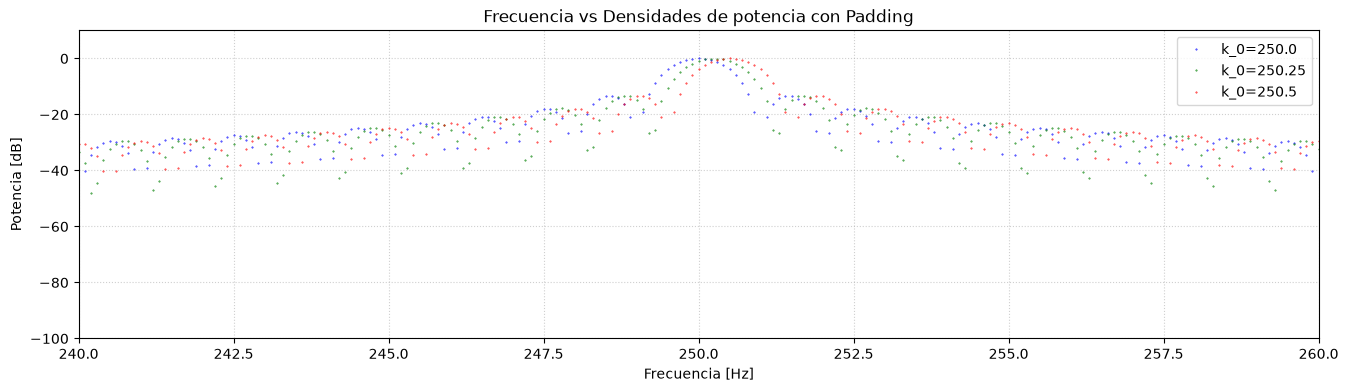

In [65]:
# Gráficos en dB
P_zero_0_db = 10 * np.log10(P_zero_0)
P_zero_1_db = 10 * np.log10(P_zero_1)
P_zero_2_db = 10 * np.log10(P_zero_2)

fig=plt.figure(figsize=(16,4))
"""
#plt.plot(frec_zero[:N_zero//2], P_zero_0_db[:N_zero//2], color='blue', label=f"k_0={k0_0}", marker=".", markersize=0.8, linestyle='solid',linewidth="0.5")
#plt.plot(frec_zero[:N_zero//2], P_zero_1_db[:N_zero//2], color='green', label=f"k_0={k0_1}", marker=".", markersize=0.8, linestyle='solid',linewidth="0.5")
#plt.plot(frec_zero[:N_zero//2], P_zero_2_db[:N_zero//2], color='red', label=f"k_0={k0_2}", marker=".", markersize=0.8, linestyle='solid',linewidth="0.5")


plt.plot(frec_zero[:N_zero//2], P_zero_0_db[:N_zero//2], color='blue', label=f"k_0={k0_0}", marker=".", markersize=0.8, linestyle="--", linewidth="0.5")
plt.plot(frec_zero[:N_zero//2], P_zero_1_db[:N_zero//2], color='green', label=f"k_0={k0_1}", marker=".", markersize=0.8, linestyle="--", linewidth="0.5")
plt.plot(frec_zero[:N_zero//2], P_zero_2_db[:N_zero//2], color='red', label=f"k_0={k0_2}", marker=".", markersize=0.8, linestyle="--",linewidth="0.5")
"""
plt.plot(frec_zero[:N_zero//2], P_zero_0_db[:N_zero//2], color='blue', label=f"k_0={k0_0}", marker=".", markersize=0.8,linestyle="None", linewidth="0.5")
plt.plot(frec_zero[:N_zero//2], P_zero_1_db[:N_zero//2], color='green', label=f"k_0={k0_1}", marker=".", markersize=0.8,linestyle="None", linewidth="0.5")
plt.plot(frec_zero[:N_zero//2], P_zero_2_db[:N_zero//2], color='red', label=f"k_0={k0_2}", marker=".", markersize=0.8,linestyle="None",linewidth="0.5")

plt.xlim(240,260)
plt.ylim(-100,10)
plt.title("Frecuencia vs Densidades de potencia con Padding")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
plt.close(fig)

Finalmente se puede observar en dB la variación de la potencia para las distintas frecuencias. Acá la envolvente de decaimiento resulta ser la misma para las tres, lo cual confirma la pérdida de energía hacia los bins vecinos, lo cual depende de la cantidad de muestras tomadas de la señal y no de la frecuencia en particular.

A lo largo de este trabajo se pudo comprobar que el desparramo espectral es consecuencia directa de cómo trabaja la FFT, donde las N muestras analizadas representan un periodo de la señal periódica infinita. Cuando la frecuencia de la señal coincide con un múltiplo entero de la resolución espectral, esa condición se cumple sin discontinuidades ni saltos bruscos, por lo que toda la energía se ve concentrada en un único bin. Cuando no se cumple, la energía debe repartirse entre varios bins vecinos para aproximar la frecuencia que la FFT no puede captar.<br>
La Identidad de Parseval permitió confirmar que esta redistribución de energía entre los bins no genera una pérdida real, dado que la potencia total calculada en el dominio temporal coinció en lo tres casos con la calculada en el frecuencia. Esto reforzó la idea de que el desparramo espectral es un problema de visualización y localización de la energía, pero no implica una variación en la misma.<br>
Finalmente, el zero padding resultó ser una herramienta útil para interpolar el espectro y visualizar con más detalle la forma real. Sin embargo, esto no elimina ni reduce el espectral. La energía perdida hacia los bins vecinos existiendo, solo que ahora puede verse con mayor detalle gracias a una resolución espectral más fina.